In [15]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats
from nbodykit.lab import *

In [16]:
snapnum = 40

In [17]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG100-3'

In [18]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/cosma7/data/dp004/dc-zhan5/TNG100-3/output/groups_040/fof_subhalo_tab_040.0.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [7]:
mhalo_tng1 = halos["Group_M_TopHat200"]
pos_tng1 = halos["GroupPos"]
sfr_tng1 = halos["GroupSFR"]

In [22]:
boxsize= 75
Nmesh = 100
nhalo = len(sfr_tng1)


halocat = np.empty(nhalo, dtype=[("Position", ("f8", 3)), ("I_nu", "f8"), ("Mass", "f8")])


halocat["I_nu"] = sfr_tng1
halocat["Position"] = np.array(pos_tng1)

ps_dict = {
    "Nhalo": nhalo,
    "halocat": halocat
}
arraycat = ArrayCatalog(ps_dict["halocat"])
weight="I_nu"
mesh = arraycat.to_mesh(resampler="nearest", BoxSize=boxsize, Nmesh=Nmesh, weight=weight)

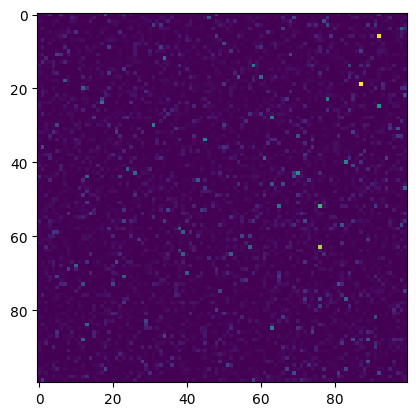

In [23]:
density = mesh.preview(Nmesh=100, axes=(0,1))
plt.imshow(density)

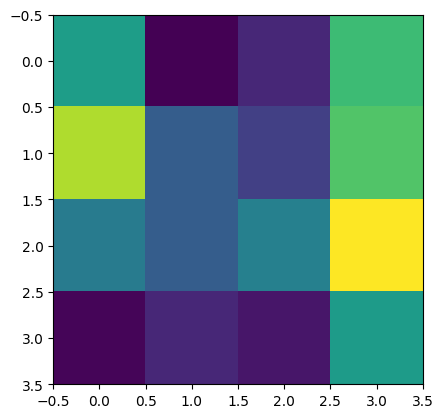

In [21]:
density = mesh.preview(Nmesh=4, axes=(0,1))
plt.imshow(density)